Clustering

Benötigte Module importieren und Datei laden. Die ersten Zeilen werden ausgegeben.

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler

path = "../../Data/diamonds.csv"

data = pd.read_csv(path, delimiter=',')

# Daten ohne Zielspalten erzeugen
data_unknown = data.drop(['cut', 'Unnamed: 0'], axis = 1)

print(data_unknown.head())

   carat color clarity  depth  table  price     x     y     z
0   0.23     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [2]:
conv_num = ['clarity', 'color']
data_unknown[conv_num] = data_unknown[conv_num].astype('category')
data_unknown[conv_num] = data_unknown[conv_num].apply(lambda x: x.cat.codes)

s_scaler = StandardScaler()

data_unknown = pd.DataFrame(s_scaler.fit_transform(data_unknown), columns = data_unknown.columns)

print(data_unknown)

          carat     color   clarity     depth     table     price         x  \
0     -1.198168 -0.937163 -0.484264 -0.174092 -1.099672 -0.904095 -1.587837   
1     -1.240361 -0.937163 -1.064117 -1.360738  1.585529 -0.904095 -1.641325   
2     -1.198168 -0.937163  0.095589 -3.385019  3.375663 -0.903844 -1.498691   
3     -1.071587  1.414272  0.675442  0.454133  0.242928 -0.902090 -1.364971   
4     -1.029394  2.002131 -0.484264  1.082358  0.242928 -0.901839 -1.240167   
...         ...       ...       ...       ...       ...       ...       ...   
53935 -0.164427 -1.525021 -1.064117 -0.662711 -0.204605 -0.294731  0.016798   
53936 -0.164427 -1.525021 -1.064117  0.942753 -1.099672 -0.294731 -0.036690   
53937 -0.206621 -1.525021 -1.064117  0.733344  1.137995 -0.294731 -0.063434   
53938  0.130927  0.826413 -0.484264 -0.523105  0.242928 -0.294731  0.373383   
53939 -0.101137 -1.525021 -0.484264  0.314528 -1.099672 -0.294731  0.088115   

              y         z  
0     -1.536196 -1.5711

C:\Users\KaratasMetin\.conda\envs\buch\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\KaratasMetin\.conda\envs\buch\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\KaratasMetin\.conda\envs\buch\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\KaratasMetin\.conda\envs\buch\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init

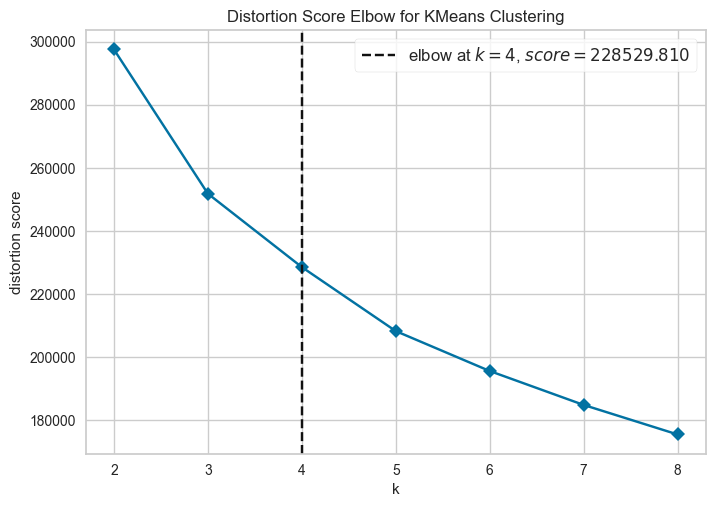

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [3]:
model = KMeans()

visualizer = KElbowVisualizer(model, k=(2,9), timings=False)
visualizer.fit(data_unknown)
visualizer.show()

In [4]:
kmeans = KMeans(n_clusters=4)

pred = kmeans.fit_predict(data_unknown)

print(pred)

C:\Users\KaratasMetin\.conda\envs\buch\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[0 0 3 ... 3 1 1]


In [5]:
data_new = pd.concat([data, pd.DataFrame(pred, columns=['label'])], axis=1)
print(data_new)

       Unnamed: 0  carat        cut color clarity  depth  table  price     x  \
0               1   0.23      Ideal     E     SI2   61.5   55.0    326  3.95   
1               2   0.21    Premium     E     SI1   59.8   61.0    326  3.89   
2               3   0.23       Good     E     VS1   56.9   65.0    327  4.05   
3               4   0.29    Premium     I     VS2   62.4   58.0    334  4.20   
4               5   0.31       Good     J     SI2   63.3   58.0    335  4.34   
...           ...    ...        ...   ...     ...    ...    ...    ...   ...   
53935       53936   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75   
53936       53937   0.72       Good     D     SI1   63.1   55.0   2757  5.69   
53937       53938   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66   
53938       53939   0.86    Premium     H     SI2   61.0   58.0   2757  6.15   
53939       53940   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83   

          y     z  label  
0      3.98 

In [6]:
# Hier sehen Sie, dass nicht die erwartete Anzahl (4 statt 5) der Gruppen erkannt wurde
print(data_new['cut'].value_counts())
print(data_new['label'].value_counts())

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
label
0    23536
1    16704
2     6944
3     6756
Name: count, dtype: int64


In [7]:
data_new.to_csv("./data_new.csv")

Vergleichen Sie die Spalte "cut" mit "label". Es wurde zwar gruppiert, aber nicht so, wie wir uns das vorgestellt haben.